In [4]:
!pip install tensorflow matplotlib numpy

   ---------------------------------------- 0.0/351.2 MB ? eta -:--:--
   ---------------------------------------- 2.4/351.2 MB 19.5 MB/s eta 0:00:18
   ---------------------------------------- 4.2/351.2 MB 12.5 MB/s eta 0:00:28
    --------------------------------------- 6.6/351.2 MB 11.9 MB/s eta 0:00:29
   - -------------------------------------- 10.0/351.2 MB 13.1 MB/s eta 0:00:27
   - -------------------------------------- 12.3/351.2 MB 12.9 MB/s eta 0:00:27
   - -------------------------------------- 14.9/351.2 MB 12.7 MB/s eta 0:00:27
   - -------------------------------------- 17.3/351.2 MB 12.4 MB/s eta 0:00:27
   -- ------------------------------------- 19.1/351.2 MB 12.1 MB/s eta 0:00:28
   -- ------------------------------------- 21.0/351.2 MB 11.6 MB/s eta 0:00:29
   -- ------------------------------------- 23.1/351.2 MB 11.4 MB/s eta 0:00:29
   -- ------------------------------------- 24.9/351.2 MB 11.3 MB/s eta 0:00:29
   --- ------------------------------------ 27.0/351


[notice] A new release of pip is available: 26.1 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [20]:
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Flatten
from tensorflow.keras.utils import to_categorical
from matplotlib import pyplot as plt
import numpy as np

from tensorflow.keras import regularizers

Load the MNIST dataset

In [6]:
(train_data,train_target),(test_data,test_target) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Visualize the dataset

Target labels:  [8 3 7 8 7 8 3 1 6 9]


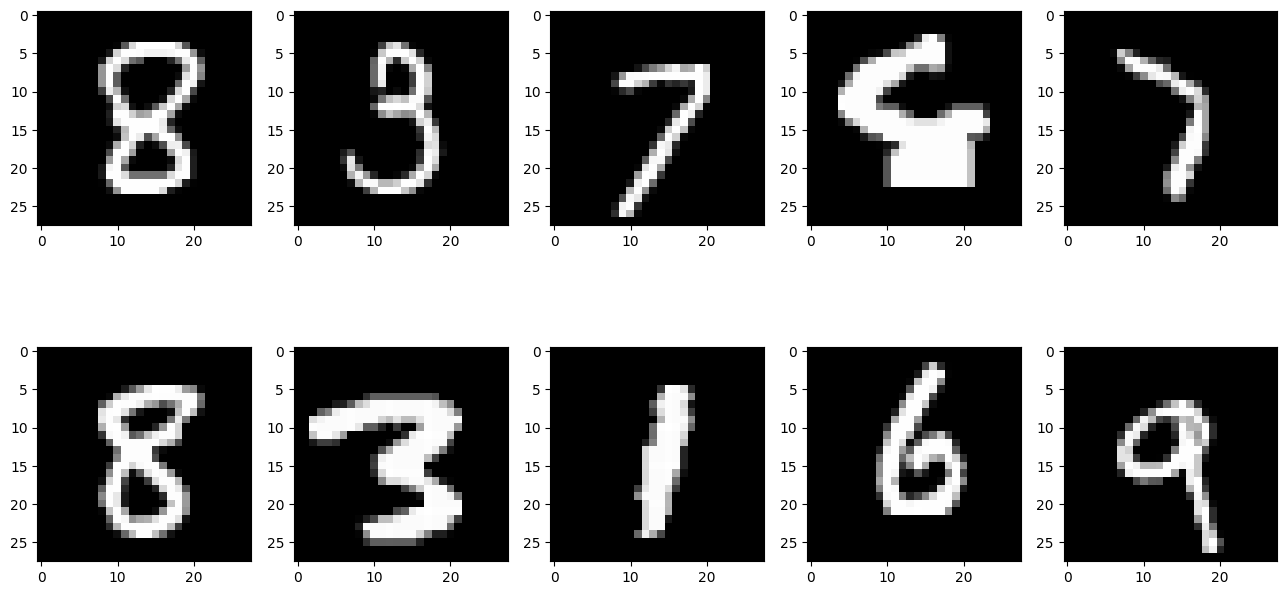

In [7]:
fig, axs = plt.subplots(2, 5, figsize=(16,8))
random_numbers = np.random.randint(0, 60000, 10)
print('Target labels: ',train_target[random_numbers])
for idx, ax in enumerate(axs.ravel()):
    ax.imshow(train_data[random_numbers[idx]],cmap='gray')
plt.show()

Pre-processing stage

In [8]:
new_train_data = train_data/255.0
new_test_data=test_data/255.0

new_train_target = to_categorical(train_target)
new_test_target = to_categorical(test_target)

Create the Model architecture

In [21]:
model=Sequential()

model.add(Flatten(input_shape=(28,28)))

model.add(Dense(
    128,
    activation='relu',
    kernel_regularizer=regularizers.l2(0.001)
))

model.add(Dense(
    64,
    activation='relu',
    kernel_regularizer=regularizers.l2(0.001)
))

model.add(Dense(
    32,
    activation='relu',
    kernel_regularizer=regularizers.l2(0.001)
))
# model.add(Dense(128,activation='relu'))
# model.add(Dense(64,input_dim=64,activation='relu'))
# model.add(Dense(32,input_dim=64,activation='relu'))
# model.add(Dense(64,activation='relu'))
# model.add(Dense(64,input_dim=64,activation='relu'))
# model.add(Dense(32,input_dim=64,activation='relu'))
model.add(Dense(10,input_dim=32,activation='softmax'))
model.compile(loss='categorical_crossentropy',optimizer='adam',metrics=['accuracy'])

In [11]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)                  │ (None, 784)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 64)                  │          50,240 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 64)                  │           4,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 10)                  │             330 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 56,810 (221.91 KB)

 Trainable params: 56,810 (221.91 KB)

 Non-trainable params: 0 (0.00 B)

Train the model

In [22]:
train_info = model.fit(new_train_data , new_train_target , epochs = 20, batch_size=64)

Epoch 1/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9056 - loss: 0.5212
Epoch 2/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9577 - loss: 0.3057
Epoch 3/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9654 - loss: 0.2588
Epoch 4/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9694 - loss: 0.2321
Epoch 5/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9725 - loss: 0.2144
Epoch 6/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9736 - loss: 0.2027
Epoch 7/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9738 - loss: 0.1944
Epoch 8/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9754 - loss: 0.1872
Epoch 9/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9758 - loss: 0.1800
Epoch 10/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9753 - loss: 0.1760
Epoch 11/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9773 - loss: 0.1680
Epoch 12/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step

Plot the loss and accuracy graphs

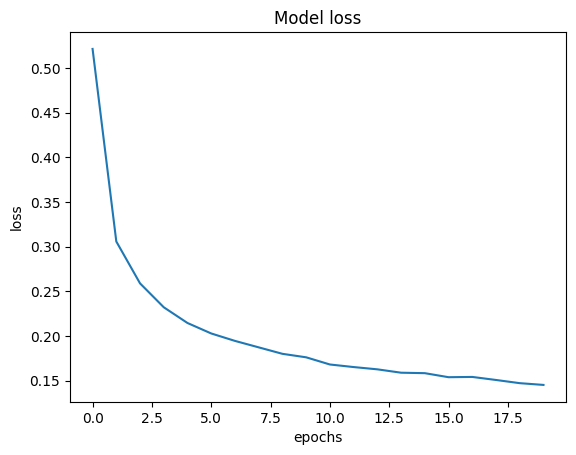

In [23]:
plt.plot(train_info.history['loss'])
plt.xlabel('epochs')
plt.ylabel('loss')
plt.title('Model loss')
plt.show()

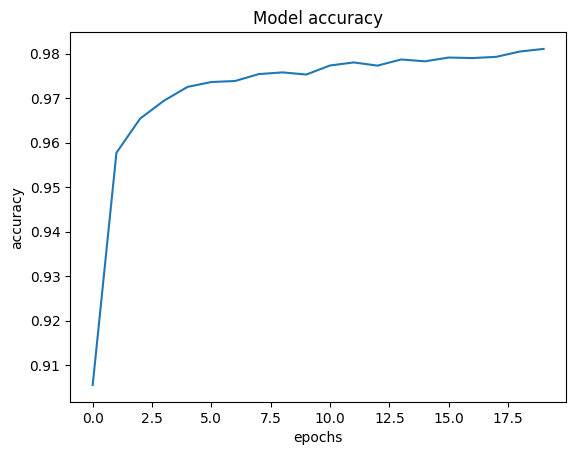

In [24]:
plt.plot(train_info.history['accuracy'])
plt.xlabel('epochs')
plt.ylabel('accuracy')
plt.title('Model accuracy')
plt.show()

Test the performance of Model

In [25]:
loss, acc = model.evaluate(new_test_data , new_test_target)
print(f'Loss of the Test dataset is: {loss}\nAccuracy of the test dataset is: {acc}')

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9754 - loss: 0.1659
Loss of the Test dataset is: 0.16585928201675415
Accuracy of the test dataset is: 0.9753999710083008


Save the model weights

In [ ]:
model.save_weights('MNIST_WEIGHTS_V1.h5')